In [2]:
import pandas as pd
df = pd.read_csv('data/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
import numpy as np

df['subscribed'] = (df['y'] == 'yes').astype(int)
BASELINE = df['subscribed'].mean()

def conversion_table(data, by):
    """按 by 列分组，计算转化率、95% Wilson 置信区间和 lift，按区间下限排序"""
    t = data.groupby(by, observed=True)['subscribed'].agg(n='size', conversions='sum').reset_index()
    n, p, z = t['n'], t['conversions'] / t['n'], 1.96
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    t['rate'] = p
    t['ci_low'] = center - margin
    t['ci_high'] = center + margin
    t['lift'] = p / BASELINE
    return t.sort_values('ci_low', ascending=False).round(3)

conversion_table(df, 'job')

,job,n,conversions,rate,ci_low,ci_high,lift
8,student,938,269,0.287,0.259,0.317,2.451
5,retired,2264,516,0.228,0.211,0.246,1.948
10,unemployed,1303,202,0.155,0.136,0.176,1.325
4,management,9458,1301,0.138,0.131,0.145,1.176
0,admin.,5171,631,0.122,0.113,0.131,1.043
9,technician,7597,840,0.111,0.104,0.118,0.945
6,self-employed,1579,187,0.118,0.103,0.135,1.012
11,unknown,288,34,0.118,0.086,0.160,1.009
7,services,4154,369,0.089,0.081,0.098,0.759
3,housemaid,1240,109,0.088,0.073,0.105,0.751


### Conversion by age
Single years of age are too granular and noisy, so ages are grouped into life-stage bins.

<Axes: title={'center': 'Conversion rate by single year of age'}, xlabel='age'>

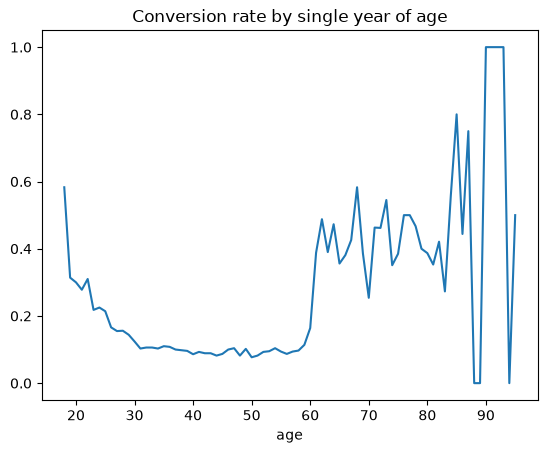

In [4]:
by_age = conversion_table(df, 'age').sort_values('age')
by_age.plot(x='age', y='rate', title='Conversion rate by single year of age', legend=False)

Text(0, 0.5, 'Conversion rate')

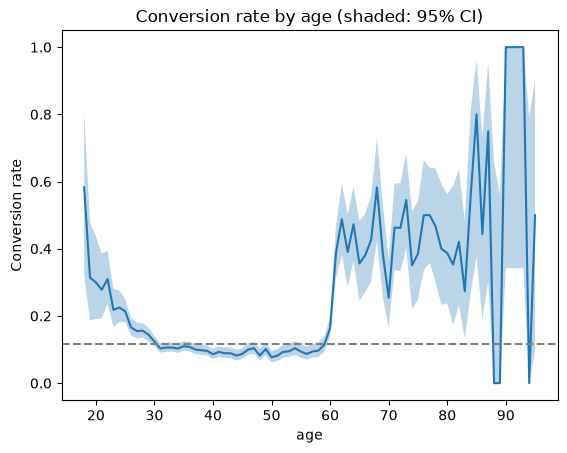

In [6]:
by_age = conversion_table(df, 'age').sort_values('age')
ax = by_age.plot(x='age', y='rate', legend=False, title='Conversion rate by age (shaded: 95% CI)')
ax.fill_between(by_age['age'], by_age['ci_low'], by_age['ci_high'], alpha=0.3)
ax.axhline(BASELINE, linestyle='--', color='gray')
ax.set_ylabel('Conversion rate')

In [7]:
df['age_group'] = pd.cut(df['age'],
                         bins=[17, 25, 30, 40, 50, 60, 100],
                         labels=['18-25', '26-30', '31-40', '41-50', '51-60', '61+'])
conversion_table(df, 'age_group').sort_values('age_group')

,age_group,n,conversions,rate,ci_low,ci_high,lift
0,18-25,1336,320,0.240,0.217,0.263,2.047
1,26-30,5694,825,0.145,0.136,0.154,1.239
2,31-40,17687,1812,0.102,0.098,0.107,0.876
3,41-50,11239,1019,0.091,0.085,0.096,0.775
4,51-60,8067,811,0.101,0.094,0.107,0.859
5,61+,1188,502,0.423,0.395,0.451,3.612


Text(0, 0.5, 'Conversion rate')

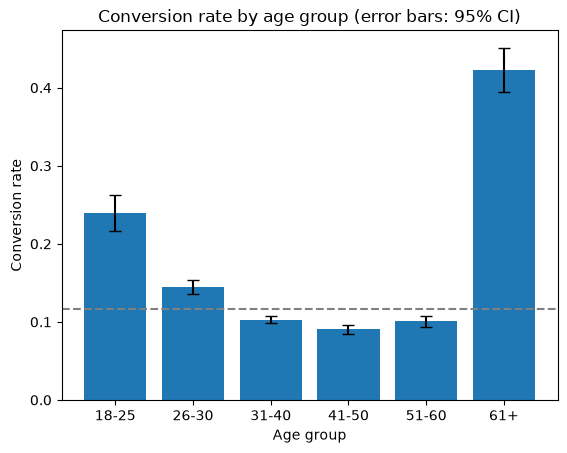

In [13]:
import matplotlib.pyplot as plt

by_group = conversion_table(df, 'age_group').sort_values('age_group')
err = [(by_group['rate'] - by_group['ci_low']).to_numpy(),
       (by_group['ci_high'] - by_group['rate']).to_numpy()]

fig, ax = plt.subplots()
ax.bar(by_group['age_group'].astype(str), by_group['rate'], yerr=err, capsize=4)
ax.axhline(BASELINE, linestyle='--', color='gray')
ax.set_title('Conversion rate by age group (error bars: 95% CI)')
ax.set_xlabel('Age group')
ax.set_ylabel('Conversion rate')

### Is it age or retirement?
Retired customers and customers aged 61+ both convert well, but they overlap heavily. Compare retired vs. non-retired customers within the same age group.

In [14]:
pd.crosstab(df['age_group'], df['job'] == 'retired')

job,False,True
age_group,,
18-25,1334,2
26-30,5692,2
31-40,17651,36
41-50,11127,112
51-60,6830,1237
61+,313,875


## Q4. When should we stop calling?
`campaign` = number of calls made to the customer during this campaign (including the last one).

,campaign,n,conversions,rate,ci_low,ci_high,lift
0,1,17544,2561,0.146,0.141,0.151,1.248
1,2,12505,1401,0.112,0.107,0.118,0.958
2,3,5521,618,0.112,0.104,0.121,0.957
3,4,3522,317,0.090,0.081,0.100,0.769
4,5,1764,139,0.079,0.067,0.092,0.674
5,6,1291,92,0.071,0.058,0.087,0.609
6,7,735,47,0.064,0.048,0.084,0.547
7,8,540,32,0.059,0.042,0.082,0.507
8,9,327,21,0.064,0.042,0.096,0.549
9,10,266,14,0.053,0.032,0.086,0.450


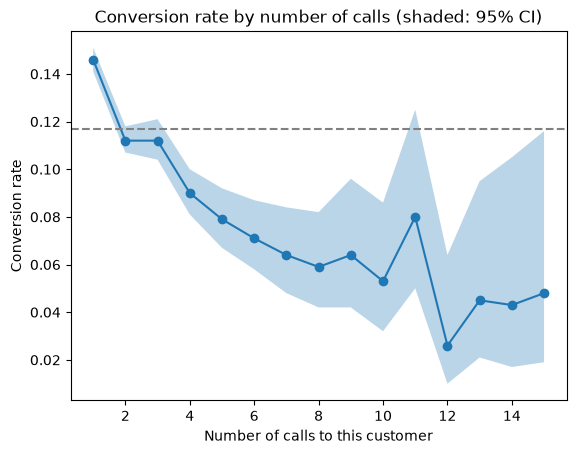

In [15]:
by_calls = conversion_table(df, 'campaign').sort_values('campaign')
top = by_calls[by_calls['campaign'] <= 15]

ax = top.plot(x='campaign', y='rate', marker='o', legend=False,
              title='Conversion rate by number of calls (shaded: 95% CI)')
ax.fill_between(top['campaign'], top['ci_low'], top['ci_high'], alpha=0.3)
ax.axhline(BASELINE, linestyle='--', color='gray')
ax.set_xlabel('Number of calls to this customer')
ax.set_ylabel('Conversion rate')

top.head(10)

The chart above suffers from **selection bias**: customers who convert early stop being called, so high call counts are dominated by hard-to-convert customers.
The decision-relevant question is: *given a customer has not converted after k−1 calls, what is the chance that call k succeeds?*

In [18]:
calls = df.groupby('campaign').agg(n=('subscribed', 'size'),
                                   conversions=('subscribed', 'sum'))
calls['reached_this_call'] = calls['n'][::-1].cumsum()[::-1]
calls['success_this_call'] = calls['conversions'] / calls['reached_this_call']
calls.head(10).round(3)

,n,conversions,reached_this_call,success_this_call
campaign,,,,
1,17544,2561,45211,0.057
2,12505,1401,27667,0.051
3,5521,618,15162,0.041
4,3522,317,9641,0.033
5,1764,139,6119,0.023
6,1291,92,4355,0.021
7,735,47,3064,0.015
8,540,32,2329,0.014
9,327,21,1789,0.012


In [19]:
total_calls = df['campaign'].sum()
total_conversions = df['subscribed'].sum()

calls_4plus = calls.loc[calls.index >= 4, 'reached_this_call'].sum()
conv_4plus = calls.loc[calls.index >= 4, 'conversions'].sum()

print(f'Total calls made:            {total_calls:,}')
print(f'Calls from the 4th onward:   {calls_4plus:,}  ({calls_4plus / total_calls:.0%} of all calls)')
print(f'Conversions from those calls: {conv_4plus:,}  ({conv_4plus / total_conversions:.0%} of all conversions)')

Total calls made:            124,956
Calls from the 4th onward:   36,850  (29% of all calls)
Conversions from those calls: 709  (13% of all conversions)


**Finding:** Each additional call is less likely to succeed. The 4th call converts at 3.3%, vs. 5.7% for a first call to a new customer.
Calls from the 4th attempt onward made up 29% of all calls but produced only 13% of conversions.
**Recommendation:** Cap at 3 calls per customer and redirect the freed capacity to first calls on new, high-priority customers.

## Q3. When and how should we call?

In [20]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
by_month = conversion_table(df, 'month').set_index('month').loc[month_order]
by_month[['n', 'rate', 'ci_low', 'ci_high', 'lift']]

,n,rate,ci_low,ci_high,lift
month,,,,,
jan,1403,0.101,0.087,0.118,0.865
feb,2649,0.166,0.153,0.181,1.423
mar,477,0.520,0.475,0.564,4.444
apr,2932,0.197,0.183,0.212,1.682
may,13766,0.067,0.063,0.071,0.574
jun,5341,0.102,0.094,0.111,0.874
jul,6895,0.091,0.084,0.098,0.777
aug,6247,0.110,0.103,0.118,0.941
sep,579,0.465,0.424,0.505,3.971


In [21]:
may_jun = df[df['month'].isin(['may', 'jun'])]
conversion_table(may_jun, ['month', 'contact']).sort_values(['month', 'contact'])

,month,contact,n,conversions,rate,ci_low,ci_high,lift
0,jun,cellular,729,320,0.439,0.403,0.475,3.752
1,jun,telephone,80,20,0.250,0.168,0.355,2.137
2,jun,unknown,4532,206,0.045,0.040,0.052,0.389
3,may,cellular,5331,633,0.119,0.110,0.128,1.015
4,may,telephone,460,31,0.067,0.048,0.094,0.576
5,may,unknown,7975,261,0.033,0.029,0.037,0.280


**Finding:** Months with very few calls (Mar, Sep, Oct, Dec: 214–738 contacts) convert at 44–52%, while May (13,766 contacts) converts at only 6.7%.
This is unlikely to be seasonality. The data spans May 2008 – Nov 2010 but has **no year column**, so each month mixes different years, economic conditions and campaign strategies (broad outreach vs. small targeted follow-ups).

Stratifying by month does **not** explain the low conversion of `contact = unknown`: within both May and June, unknown still converts far below cellular. Month alone is too coarse to control for the time period.

**Conclusion:** Month and contact method are confounded with time, so no timing or channel recommendation is made. This is listed as a limitation.

## Q5. If we can only contact 22% of customers, who should we pick?
Rank job × age-group segments by conversion on a **training set (70%)**, then evaluate the ranking on a held-out **test set (30%)** that plays the role of "next quarter's customers".

In [22]:
train = df.sample(frac=0.7, random_state=42) #随机抽取70%的行作为训练集。
test = df.drop(train.index) #把训练集的行去掉，剩下的30%就是测试集。

seg_rank = conversion_table(train, ['job', 'age_group']) #按"职业 × 年龄段"分组，算出每个群体的转化率，并按区间下限排好序
print(f'Train: {len(train):,} rows   Test: {len(test):,} rows   Segments: {len(seg_rank)}')
seg_rank.head(10)

Train: 31,648 rows   Test: 13,563 rows   Segments: 70


,job,age_group,n,conversions,rate,ci_low,ci_high,lift
41,self-employed,61+,18,12,0.667,0.437,0.837,5.699
35,retired,61+,630,263,0.417,0.380,0.456,3.569
29,management,61+,75,34,0.453,0.346,0.566,3.875
48,student,18-25,297,106,0.357,0.305,0.413,3.051
5,admin.,61+,18,9,0.500,0.290,0.710,4.274
17,entrepreneur,61+,9,5,0.556,0.267,0.811,4.749
23,housemaid,61+,38,15,0.395,0.256,0.553,3.374
24,management,18-25,78,23,0.295,0.205,0.404,2.521
49,student,26-30,252,62,0.246,0.197,0.303,2.103
36,self-employed,18-25,20,7,0.350,0.181,0.567,2.992


In [23]:
scored = test.merge(seg_rank[['job', 'age_group', 'ci_low']],
                    on=['job', 'age_group'], how='left')
scored['ci_low'] = scored['ci_low'].fillna(0)

budget = int(len(scored) * 0.22)
picked = scored.sort_values('ci_low', ascending=False).head(budget)

test_rate = scored['subscribed'].mean()
picked_rate = picked['subscribed'].mean()

print(f'Budget: contact {budget:,} of {len(scored):,} test customers (22%)')
print(f'Random selection : {test_rate:.1%} conversion  -> about {budget * test_rate:,.0f} conversions')
print(f'Our ranking      : {picked_rate:.1%} conversion  -> {picked["subscribed"].sum():,} conversions')
print(f'Lift             : {picked_rate / test_rate:.2f}x')

Budget: contact 2,983 of 13,563 test customers (22%)
Random selection : 11.6% conversion  -> about 347 conversions
Our ranking      : 18.4% conversion  -> 548 conversions
Lift             : 1.58x


**Result (held-out test set):** contacting the top 22% of customers ranked by job × age-group segment converts at **18.4%** vs. **11.6%** for a random 22%, i.e. **548 vs. ~347 conversions (+58%, lift 1.58x)** for the same number of customers contacted.

Because the ranking was built on the training set only, this estimates how the strategy would perform on next quarter's customers.